In [1]:
# @title 1a. Install kagglehub & mount Google Drive
!pip install -q kagglehub

from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from tqdm.auto import tqdm

sns.set_style("whitegrid")


def set_seed(seed: int = 42):
    """Set semua random seed agar hasil reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {DEVICE}")

Menggunakan device: cuda


In [3]:
# @title 4a. Download APTOS 2019 (kagglehub, sudah 224x224)
import kagglehub

aptos_path = kagglehub.dataset_download(
    "sovitrath/diabetic-retinopathy-224x224-2019-data"
)
print("Path to dataset files:", aptos_path)

# struktur dataset ini: <aptos_path>/train.csv + <aptos_path>/colored_images/<kelas>/<id_code>.png
!ls "{aptos_path}"

100%|██████████| 238M/238M [00:01<00:00, 128MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sovitrath/diabetic-retinopathy-224x224-2019-data/versions/4
colored_images	train.csv


In [4]:
# @title 4b. Copy dataset lokal dari Google Drive ke disk lokal Colab
import glob

# LOCAL_DR_DIR_DRIVE = "/content/drive/MyDrive/BayesianCNN/Dataset/Lokal"
# LOCAL_DR_DIR = "/content/data/local_raw"  # <- dari sini seterusnya, ini yang dipakai (bukan path Drive)

# def copy_drive_to_local(src_dir, dst_dir):
#     os.makedirs(dst_dir, exist_ok=True)
#     all_files = [f for f in glob.glob(os.path.join(src_dir, "**", "*"), recursive=True) if os.path.isfile(f)]
#     copied, skipped = 0, 0
#     for src_fp in tqdm(all_files, desc="Copy Drive -> lokal Colab"):
#         rel_path = os.path.relpath(src_fp, src_dir)
#         dst_fp = os.path.join(dst_dir, rel_path)
#         os.makedirs(os.path.dirname(dst_fp), exist_ok=True)
#         if os.path.exists(dst_fp) and os.path.getsize(dst_fp) == os.path.getsize(src_fp):
#             skipped += 1
#             continue
#         shutil.copy2(src_fp, dst_fp)
#         copied += 1
#     print(f"Selesai copy: {copied} file baru, {skipped} file sudah ada (di-skip, idempotent kalau re-run).")

# copy_drive_to_local(LOCAL_DR_DIR_DRIVE, LOCAL_DR_DIR)

# print("Isi folder lokal:")
# for cls in ["No_DR", "Mild", "Moderate", "Severe", "Proliferate_DR"]:
#     n = len(glob.glob(os.path.join(LOCAL_DR_DIR, cls, "*")))
#     print(f"  {cls}: {n} file")

In [5]:
# @title 5a. Build unified dataframe (APTOS + lokal, sama-sama struktur class_folders)
CLASS_ALIASES = {
    "No_DR": ["No_DR", "0"],
    "Mild": ["Mild", "1"],
    "Moderate": ["Moderate", "2"],
    "Severe": ["Severe", "3"],
    "Proliferate_DR": ["Proliferate_DR", "4"],
}


def load_class_folder_df(root_dir, source_name):
    rows = []
    for label, aliases in CLASS_ALIASES.items():
        folder_path = next(
            (
                os.path.join(root_dir, a)
                for a in aliases
                if os.path.isdir(os.path.join(root_dir, a))
            ),
            None,
        )
        if folder_path is None:
            continue
        for fp in glob.glob(os.path.join(folder_path, "*")):
            if fp.lower().endswith((".png", ".jpg", ".jpeg")):
                rows.append({"filepath": fp, "label": label, "source": source_name})
    return pd.DataFrame(rows)


aptos_df = load_class_folder_df(os.path.join(aptos_path, "colored_images"), "aptos")
print("Aptos")
print(aptos_df["label"].value_counts().sort_index())
print("\n")

# local_df = load_class_folder_df(LOCAL_DR_DIR, "local")
# print("Local")
# print(local_df["label"].value_counts().sort_index())
# print("\n")

full_df = pd.concat([aptos_df], ignore_index=True)
full_df = full_df[full_df["filepath"].apply(os.path.exists)].reset_index(drop=True)
df_shuffled = full_df.sample(frac=1, random_state=42).reset_index(drop=True)
print(
    "APTOS:",
    len(aptos_df),
    "| Local:",
    len([0]),
    "| combined (valid files):",
    len(df_shuffled),
)
print(df_shuffled["label"].value_counts().sort_index())

Aptos
label
Mild               370
Moderate           999
No_DR             1805
Proliferate_DR     295
Severe             193
Name: count, dtype: int64


APTOS: 3662 | Local: 1 | combined (valid files): 3662
label
Mild               370
Moderate           999
No_DR             1805
Proliferate_DR     295
Severe             193
Name: count, dtype: int64


In [ ]:
# @title 6a. Preprocessing functions

import cv2

cv2.setNumThreads(0)


def _detect_retina_circle(gray, thresh=7):
    mask = gray > thresh
    if mask.sum() == 0:
        return None
    coords = np.argwhere(mask)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0)
    return x0, y0, x1, y1


def _scale_radius(img, target_radius=300):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    row = gray[gray.shape[0] // 2, :]
    row_thresh = row > row.mean() / 10
    nz = np.nonzero(row_thresh)[0]
    if len(nz) < 2:
        return img
    current_radius = (nz[-1] - nz[0]) / 2
    if current_radius <= 1:
        return img
    scale = target_radius / current_radius
    scale = float(np.clip(scale, 0.1, 10.0))
    return cv2.resize(img, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)


def _circular_mask(img, radius_fraction=0.90):
    # standar Ben Graham: clip ke ~90% radius untuk buang artefak di tepi retina
    h, w = img.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)
    center = (w // 2, h // 2)
    radius = int(min(h, w) / 2 * radius_fraction)
    cv2.circle(mask, center, radius, 255, -1)
    out = cv2.bitwise_and(img, img, mask=mask)
    return out


def _denoise(img, ksize=3):
    # median filter ringan: buang noise SEBELUM contrast enhancement,
    # supaya CLAHE tidak ikut menguatkan noise-nya
    return cv2.medianBlur(img, ksize)


def _clahe_green_channel(img_rgb, clip_limit=2.5, tile=(8, 8)):
    # CLAHE khusus di green channel: channel ini punya kontras terbaik
    # untuk pembuluh darah & lesi pada fundus image. R & B dibiarkan
    # apa adanya supaya rekonstruksi RGB tetap valid untuk backbone
    # CNN pretrained (ResNet/DenseNet dkk mengharapkan input 3-channel).
    r, g, b = cv2.split(img_rgb)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile)
    g_eq = clahe.apply(g)
    return cv2.merge((r, g_eq, b))


def _local_average_subtract(img, sigma_fraction=30):
    # Ben Graham illumination normalization: img*4 - blur(img)*4 + 128
    sigma = max(img.shape[0], img.shape[1]) / sigma_fraction
    blurred = cv2.GaussianBlur(img, (0, 0), sigma)
    out = cv2.addWeighted(img, 4, blurred, -4, 128)
    return out


def preprocess_image(img_rgb, img_size=224, target_radius=300, debug_stats=None):
    """Full pipeline: crop -> radius normalize -> circular mask (90%) -> denoise
    -> CLAHE (green channel) -> Ben Graham illumination normalize -> resize.
    Falls back to the ORIGINAL image if any stage fails, to avoid discarding data."""
    original = img_rgb  # simpan referensi ke input asli yang belum disentuh
    try:
        gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
        box = _detect_retina_circle(gray, thresh=7)
        if box is not None:
            x0, y0, x1, y1 = box
            if (x1 - x0) > 10 and (y1 - y0) > 10:
                img_rgb = img_rgb[y0:y1, x0:x1]
        img_rgb = _scale_radius(img_rgb, target_radius=target_radius)
        img_rgb = _circular_mask(img_rgb, radius_fraction=0.90)
        img_rgb = _denoise(img_rgb, ksize=3)
        img_rgb = _clahe_green_channel(img_rgb, clip_limit=2.5, tile=(8, 8))
        img_rgb = _local_average_subtract(img_rgb, sigma_fraction=30)
    except Exception as e:
        img_rgb = (
            original  # benar-benar kembali ke gambar asli, bukan array setengah-jadi
        )
        if debug_stats is not None:
            debug_stats["failed"] = debug_stats.get("failed", 0) + 1
            debug_stats.setdefault("errors", []).append(str(e))

    # square-pad before resize to avoid distortion
    h, w = img_rgb.shape[:2]
    side = max(h, w)
    padded = np.zeros((side, side, 3), dtype=img_rgb.dtype)
    y_off, x_off = (side - h) // 2, (side - w) // 2
    padded[y_off : y_off + h, x_off : x_off + w] = img_rgb
    out = cv2.resize(padded, (img_size, img_size), interpolation=cv2.INTER_AREA)
    return out

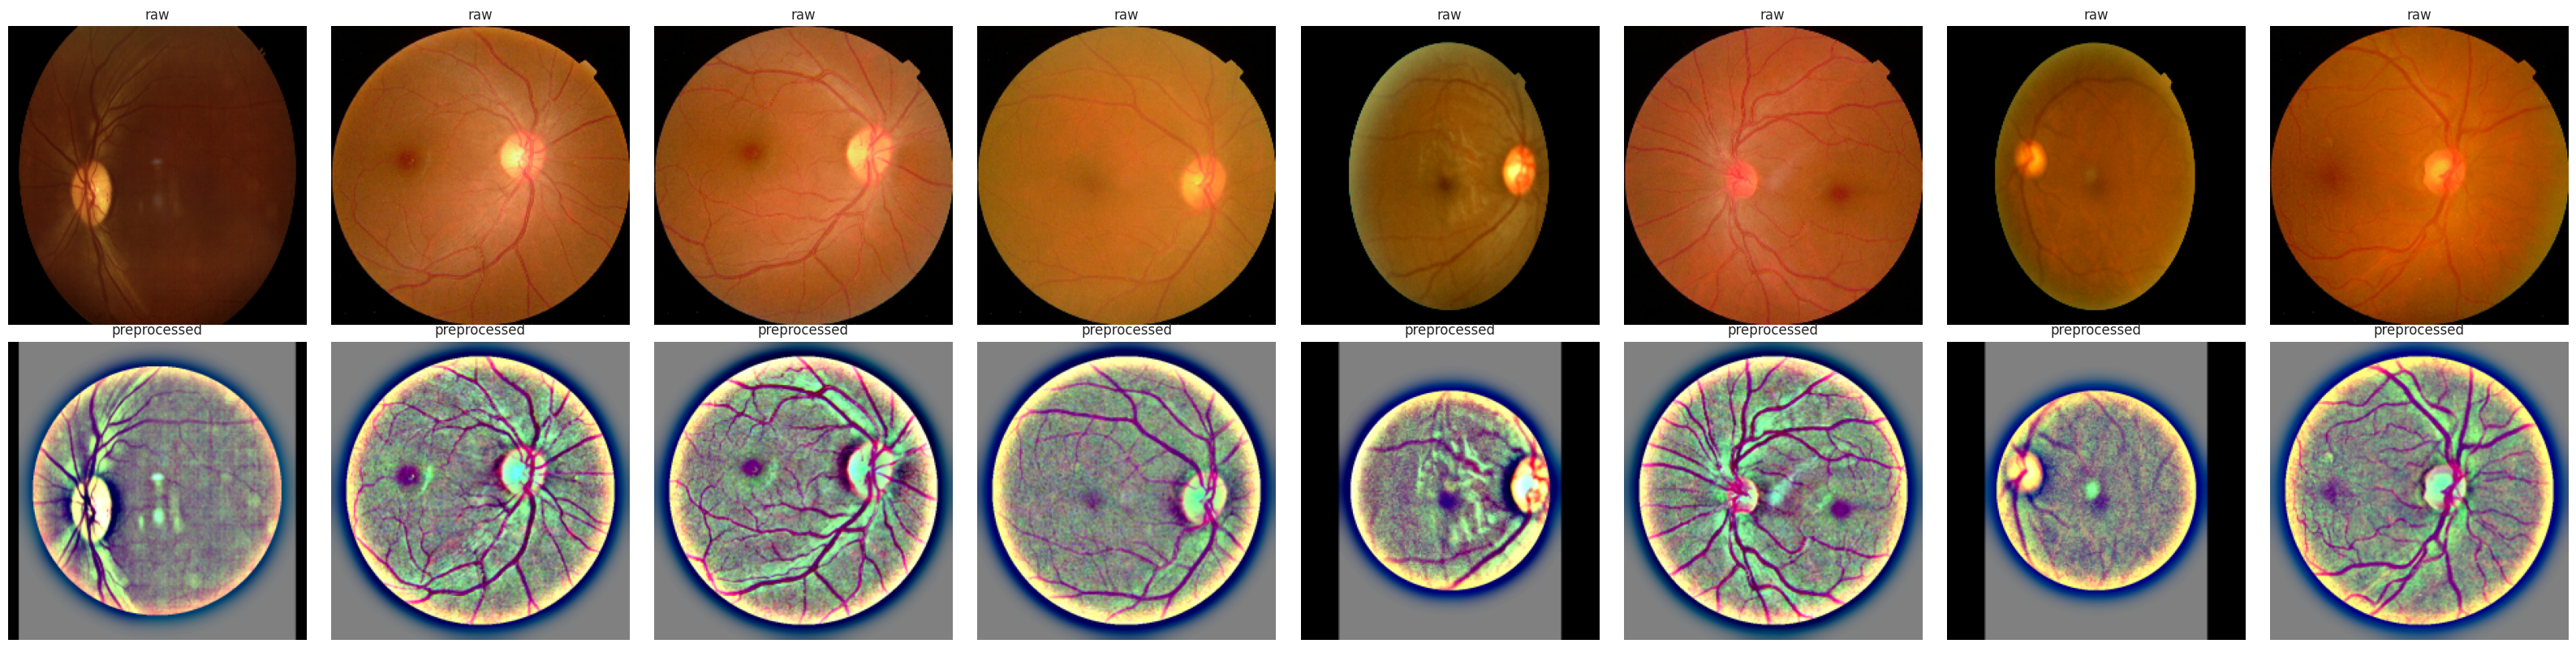

In [7]:
# @title 6b. Sanity check preprocessing on sample images
def _load_rgb(path):
    img = cv2.imread(path)
    if img is None:
        raise ValueError(f"Gagal membaca gambar (file korup/tidak didukung): {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


aptos_sample_paths = glob.glob(f"{aptos_path}/**/*.png", recursive=True)[:8]
if len(aptos_sample_paths) > 0:
    fig, axes = plt.subplots(
        2, len(aptos_sample_paths), figsize=(4 * len(aptos_sample_paths), 8)
    )
    for i, p in enumerate(aptos_sample_paths):
        raw = _load_rgb(p)
        proc = preprocess_image(raw)
        axes[0, i].imshow(raw)
        axes[0, i].set_title("raw")
        axes[0, i].axis("off")
        axes[1, i].imshow(proc)
        axes[1, i].set_title("preprocessed")
        axes[1, i].axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No sample aptos images found yet - run the download cells first.")

print("\n")

# local_sample_paths = glob.glob(f"{LOCAL_DR_DIR}/**/*.jpg", recursive=True)[:8]
# if len(local_sample_paths) > 0:
#     fig, axes = plt.subplots(2, len(local_sample_paths), figsize=(4 * len(local_sample_paths), 8))
#     for i, p in enumerate(local_sample_paths):
#         raw = _load_rgb(p)
#         proc = preprocess_image(raw)
#         axes[0, i].imshow(raw); axes[0, i].set_title("raw"); axes[0, i].axis("off")
#         axes[1, i].imshow(proc); axes[1, i].set_title("preprocessed"); axes[1, i].axis("off")
#     plt.tight_layout(); plt.show()
# else:
#     print("No sample local images found yet - run the download cells first.")

In [8]:
# @title 7a. Train/val/test split (stratified)

train_df, temp_df = train_test_split(
    full_df, test_size=0.30, stratify=full_df["label"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print("\nDistribusi label per split (proporsi):")
dist = pd.DataFrame(
    {
        "full": full_df["label"].value_counts(normalize=True),
        "train": train_df["label"].value_counts(normalize=True),
        "val": val_df["label"].value_counts(normalize=True),
        "test": test_df["label"].value_counts(normalize=True),
    }
)
print(dist.round(3))

Train: 2563 | Val: 549 | Test: 550

Distribusi label per split (proporsi):
                 full  train    val   test
label                                     
No_DR           0.493  0.493  0.494  0.493
Moderate        0.273  0.273  0.273  0.273
Mild            0.101  0.101  0.100  0.102
Proliferate_DR  0.081  0.081  0.080  0.080
Severe          0.053  0.053  0.053  0.053


In [ ]:
# @title 7b-0. Precompute preprocessing cache (jalankan SEKALI sebelum training)
import hashlib

CACHE_DIR = "/content/preprocess_cache"
os.makedirs(CACHE_DIR, exist_ok=True)


def _cache_path(filepath, img_size=224):
    h = hashlib.md5(f"{filepath}_{img_size}".encode()).hexdigest()
    return os.path.join(CACHE_DIR, f"{h}.png")


def precompute_cache(df, img_size=224):
    """Jalankan preprocess_image SEKALI utk tiap gambar unik, simpan hasilnya sbg
    PNG 224x224 di CACHE_DIR. Idempotent: kalau file cache sudah ada, dilewati
    (aman dipanggil ulang / lanjut kalau sesi Colab keputus di tengah jalan)."""
    n_done, n_skip, n_fail = 0, 0, 0
    for fp in tqdm(df["filepath"].unique(), desc="Precompute cache"):
        cpath = _cache_path(fp, img_size)
        if os.path.exists(cpath):
            n_skip += 1
            continue
        img_bgr = cv2.imread(fp)
        if img_bgr is None:
            print(f"WARNING: gagal load {fp}, dilewati")
            n_fail += 1
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_proc = preprocess_image(img_rgb, img_size=img_size)
        cv2.imwrite(cpath, cv2.cvtColor(img_proc, cv2.COLOR_RGB2BGR))
        n_done += 1
    print(
        f"Selesai: {n_done} gambar baru di-cache, {n_skip} sudah ada (skip), {n_fail} gagal."
    )


precompute_cache(
    full_df, img_size=224
)  # sekali jalan utk seluruh dataset (train+val+test)

In [ ]:
# @title 7b. Custom PyTorch Dataset (dgn cache preprocessing)


class DRDataset(Dataset):
    LABEL_TO_IDX = {
        "No_DR": 0,
        "Mild": 1,
        "Moderate": 2,
        "Severe": 3,
        "Proliferate_DR": 4,
    }

    def __init__(self, df, img_size=224, transform=None, use_cache=True):
        self.df = df.reset_index(drop=True)
        self.img_size = img_size
        self.transform = transform
        self.use_cache = use_cache

    def __len__(self):
        return len(self.df)

    def _load_processed(self, filepath):
        if self.use_cache:
            cpath = _cache_path(filepath, self.img_size)
            if os.path.exists(cpath):
                img_bgr = cv2.imread(cpath)
                return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        # cache miss (atau use_cache=False) -> proses dari file asli seperti biasa
        img_bgr = cv2.imread(filepath)
        if img_bgr is None:
            raise ValueError(f"Gagal membaca gambar: {filepath}")
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        return preprocess_image(img_rgb, img_size=self.img_size)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_proc = self._load_processed(row["filepath"])
        img_pil = Image.fromarray(img_proc)

        if self.transform is not None:
            img_tensor = self.transform(img_pil)
        else:
            img_tensor = transforms.ToTensor()(img_pil)

        label_idx = self.LABEL_TO_IDX[row["label"]]
        return img_tensor, label_idx

In [10]:
# @title 7c. Transforms (augmentation + normalisasi) & instansiasi Dataset
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# augmentasi hanya untuk train; val/test cuma normalisasi (evaluasi harus deterministik)
train_transform = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=20),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)

eval_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)

train_dataset = DRDataset(train_df, img_size=IMG_SIZE, transform=train_transform)
val_dataset = DRDataset(val_df, img_size=IMG_SIZE, transform=eval_transform)
test_dataset = DRDataset(test_df, img_size=IMG_SIZE, transform=eval_transform)

# sanity check satu sampel
sample_img, sample_label = train_dataset[0]
print(
    "Sample image tensor:", sample_img.shape, sample_img.dtype, "| label:", sample_label
)

Sample image tensor: torch.Size([3, 224, 224]) torch.float32 | label: 4


In [ ]:
# @title 7d. DataLoader + imbalance handling
from torch.utils.data import WeightedRandomSampler

# WeightedRandomSampler: kelas minoritas (Severe, Proliferate_DR) di-oversample
# secara acak per-batch, supaya training tidak bias ke No_DR/Moderate yang dominan
class_counts = train_df["label"].value_counts()
class_weight_map = {cls: 1.0 / count for cls, count in class_counts.items()}
sample_weights = train_df["label"].map(class_weight_map).values

train_sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True
)

BATCH_SIZE = 64
NUM_WORKERS = 0  # aman untuk Colab; naikkan kalau RAM/CPU cukup

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print(
    f"Train data: {len(train_dataset)} | Val data: {len(val_dataset)} | Test data: {len(test_dataset)}"
)
print(
    f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}"
)

imgs, labels = next(iter(train_loader))
print("Batch images:", imgs.shape, "| Batch labels:", labels.shape)
print(
    "Distribusi label dalam 1 batch (harusnya lebih merata krn sampler):",
    labels.bincount(),
)

Train batches: 41 | Val batches: 9 | Test batches: 9
Batch images: torch.Size([64, 3, 224, 224]) | Batch labels: torch.Size([64])
Distribusi label dalam 1 batch (harusnya lebih merata krn sampler): tensor([16,  9, 12, 12, 15])


In [ ]:
# @title 8a. Bayesian CNN model (DenseNet-121 backbone + MC Dropout) & MC Dropout helpers
NUM_CLASSES = 5
DROPOUT_P = 0.3


class BayesianDRNet(nn.Module):
    """DenseNet-121 pretrained sebagai feature extractor + classifier head dengan
    Dropout. Dropout ini yang jadi 'Bayesian' approximation-nya (Gal & Ghahramani,
    MC Dropout): kalau tetap aktif saat inference dan di-sample berkali-kali,
    variasi antar sample merepresentasikan epistemic uncertainty model."""

    def __init__(self, num_classes=NUM_CLASSES, dropout_p=DROPOUT_P, pretrained=True):
        super().__init__()
        weights = models.DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = models.densenet121(weights=weights)
        in_features = backbone.classifier.in_features  # 1024 utk densenet121
        backbone.classifier = (
            nn.Identity()
        )  # buang classifier bawaan, ambil fiturnya saja
        self.backbone = backbone
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout_p),
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        features = self.backbone(x)
        logits = self.classifier(features)
        return logits


def enable_mc_dropout(model: nn.Module):
    """Set model ke eval mode (BatchNorm pakai running stats), TAPI paksa semua
    layer nn.Dropout tetap aktif -> ini kunci MC Dropout saat inference."""
    model.eval()
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.train()


@torch.no_grad()
def mc_dropout_predict(model: nn.Module, x: torch.Tensor, T: int = 25):
    """Jalankan T forward pass dengan dropout aktif, lalu hitung:
    - mean_probs            : rata-rata probabilitas softmax (prediksi akhir)
    - predictive_entropy    : total uncertainty (aleatoric + epistemic)
    - aleatoric_entropy     : rata-rata entropy tiap sample (uncertainty dari data)
    - epistemic_uncertainty : mutual information/BALD = predictive - aleatoric,
      merepresentasikan seberapa 'model tidak yakin karena kurang belajar'
    """
    enable_mc_dropout(model)
    probs_samples = []
    for _ in range(T):
        logits = model(x)
        probs = F.softmax(logits, dim=1)
        probs_samples.append(probs.unsqueeze(0))
    probs_samples = torch.cat(probs_samples, dim=0)  # (T, B, num_classes)

    mean_probs = probs_samples.mean(dim=0)  # (B, num_classes)
    eps = 1e-12
    predictive_entropy = -(mean_probs * torch.log(mean_probs + eps)).sum(dim=1)  # (B,)
    per_sample_entropy = -(probs_samples * torch.log(probs_samples + eps)).sum(
        dim=2
    )  # (T, B)
    aleatoric_entropy = per_sample_entropy.mean(dim=0)  # (B,)
    epistemic_uncertainty = (
        predictive_entropy - aleatoric_entropy
    )  # (B,) >= 0 secara teori

    return {
        "mean_probs": mean_probs,
        "predictive_entropy": predictive_entropy,
        "aleatoric_entropy": aleatoric_entropy,
        "epistemic_uncertainty": epistemic_uncertainty,
    }


model = BayesianDRNet(num_classes=NUM_CLASSES, dropout_p=DROPOUT_P, pretrained=True).to(
    DEVICE
)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model dibuat. Trainable params: {n_params:,}")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 158MB/s]

Model dibuat. Trainable params: 7,217,541


In [13]:
# @title 8b. Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss()
# NB: imbalance sudah ditangani via WeightedRandomSampler di cell 7d,
# jadi tidak perlu class-weight lagi di loss (hindari double-compensate)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3
)

In [ ]:
# @title (Diagnostik) Ukur waktu: data loading vs GPU compute
import time

# 1) waktu ambil beberapa batch dari DataLoader (murni data loading + preprocessing, TANPA training)
n_batches_test = 5
t0 = time.time()
it = iter(train_loader)
for _ in range(n_batches_test):
    imgs, labels = next(it)
t_dataload = time.time() - t0
img_per_sec_load = imgs.shape[0] * n_batches_test / t_dataload
print(
    f"[Data loading] {n_batches_test} batch: {t_dataload:.2f}s "
    f"({t_dataload / n_batches_test:.2f}s/batch, {img_per_sec_load:.1f} gambar/detik)"
)

# 2) waktu forward+backward GPU murni (pakai batch yg SAMA, diulang, tanpa data loading baru)
imgs_gpu, labels_gpu = imgs.to(DEVICE), labels.to(DEVICE)
model.train()
if DEVICE.type == "cuda":
    torch.cuda.synchronize()
t0 = time.time()
n_iter_test = 10
for _ in range(n_iter_test):
    optimizer.zero_grad()
    logits = model(imgs_gpu)
    loss = criterion(logits, labels_gpu)
    loss.backward()
    optimizer.step()
if DEVICE.type == "cuda":
    torch.cuda.synchronize()
t_gpu = time.time() - t0
img_per_sec_gpu = imgs_gpu.shape[0] * n_iter_test / t_gpu
print(
    f"[GPU compute]  {n_iter_test}x forward+backward (batch sama): {t_gpu:.2f}s "
    f"({t_gpu / n_iter_test * 1000:.1f} ms/iterasi, {img_per_sec_gpu:.1f} gambar/detik)"
)

print(f"\nRasio GPU vs data-loading: {img_per_sec_gpu / img_per_sec_load:.1f}x")
print(
    "Kalau rasio ini >> 1 (misal >5x), artinya GPU jauh lebih cepat dari data loading"
)
print("-> GPU nganggur nunggu CPU, preprocessing/cv2 adalah bottleneck-nya.")

In [ ]:
# @title 8c. Training loop
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []
    pbar = tqdm(loader, desc="Train", leave=False)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
        pbar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")
    return epoch_loss, epoch_acc, epoch_qwk


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evaluasi standar (deterministik, dropout OFF) -> dipakai tiap epoch untuk
    validation. MC Dropout dengan T-sample dipakai terpisah nanti khusus untuk
    analisis uncertainty final (cell 9), bukan tiap epoch, karena T kali lebih mahal."""
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []
    pbar = tqdm(loader, desc="Train", leave=False)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        loss = criterion(logits, labels)
        running_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        pbar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")
    return epoch_loss, epoch_acc, epoch_qwk


N_EPOCHS = 25
PATIENCE = 5  # early stopping
CKPT_PATH = "BCNN_PyTorch_(2).pt"

history = {
    "train_loss": [],
    "train_acc": [],
    "train_qwk": [],
    "val_loss": [],
    "val_acc": [],
    "val_qwk": [],
}

best_val_qwk = -1.0
epochs_no_improve = 0

for epoch in range(1, N_EPOCHS + 1):
    train_loss, train_acc, train_qwk = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE
    )
    val_loss, val_acc, val_qwk = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step(val_qwk)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_qwk"].append(train_qwk)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_qwk"].append(val_qwk)

    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch {epoch:02d}/{N_EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} train_qwk={train_qwk:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_qwk={val_qwk:.4f} | lr={current_lr:.2e}"
    )

    if val_qwk > best_val_qwk:
        best_val_qwk = val_qwk
        epochs_no_improve = 0
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "epoch": epoch,
                "val_qwk": val_qwk,
            },
            CKPT_PATH,
        )
        print(f"  -> checkpoint disimpan (val_qwk={val_qwk:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(
                f"Early stopping di epoch {epoch} (tidak ada peningkatan val_qwk selama {PATIENCE} epoch)."
            )
            break

print(f"\nTraining selesai. Best val QWK: {best_val_qwk:.4f} (checkpoint: {CKPT_PATH})")

Train:   0%|          | 0/41 [00:00<?, ?it/s]

Epoch 01/30 | train_loss=1.3677 train_acc=0.4253 train_qwk=0.5346 | val_loss=0.8378 val_acc=0.6612 val_qwk=0.7891 | lr=1.00e-04
  -> checkpoint disimpan (val_qwk=0.7891)


Train:   0%|          | 0/41 [00:00<?, ?it/s]

Epoch 02/30 | train_loss=0.9908 train_acc=0.5977 train_qwk=0.7361 | val_loss=0.7175 val_acc=0.6794 val_qwk=0.7897 | lr=1.00e-04
  -> checkpoint disimpan (val_qwk=0.7897)


Train:   0%|          | 0/41 [00:00<?, ?it/s]

...

Epoch 14/30 | train_loss=0.2727 train_acc=0.9044 train_qwk=0.9459 | val_loss=0.7391 val_acc=0.7668 val_qwk=0.8489 | lr=5.00e-05


Train:   0%|          | 0/41 [00:00<?, ?it/s]

Epoch 15/30 | train_loss=0.2176 train_acc=0.9263 train_qwk=0.9563 | val_loss=0.7410 val_acc=0.7668 val_qwk=0.8426 | lr=5.00e-05


Train:   0%|          | 0/41 [00:00<?, ?it/s]

Epoch 16/30 | train_loss=0.2009 train_acc=0.9294 train_qwk=0.9588 | val_loss=0.7307 val_acc=0.7814 val_qwk=0.8608 | lr=5.00e-05
Early stopping di epoch 16 (tidak ada peningkatan val_qwk selama 7 epoch).

Training selesai. Best val QWK: 0.8620 (checkpoint: best_bcnn_dr.pt)


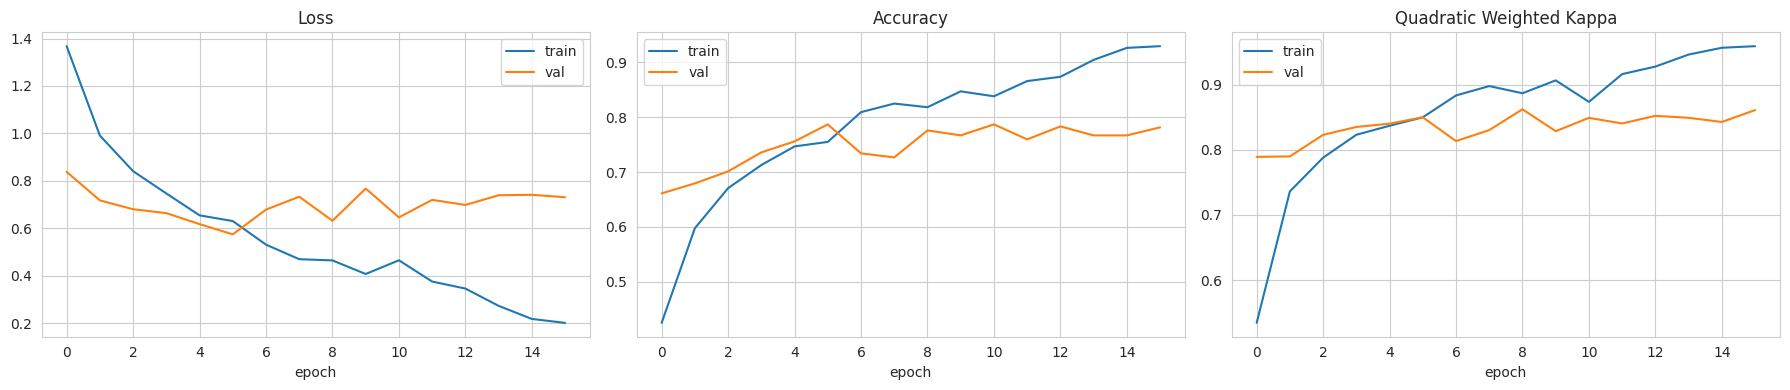

In [18]:
# @title 8d. Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
metrics = [("loss", "Loss"), ("acc", "Accuracy"), ("qwk", "Quadratic Weighted Kappa")]
for ax, (key, title) in zip(axes, metrics):
    ax.plot(history[f"train_{key}"], label="train")
    ax.plot(history[f"val_{key}"], label="val")
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.legend()
plt.tight_layout()
plt.show()

In [20]:
def load_best_checkpoint(model, ckpt_path, device):
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    print(
        f"Checkpoint dimuat dari epoch {ckpt['epoch']} (val_qwk={ckpt['val_qwk']:.4f})"
    )
    return model


model = load_best_checkpoint(model, CKPT_PATH, DEVICE)

T_MC = 20  # jumlah forward pass MC Dropout saat inference

all_preds = []
all_labels = []
all_mean_probs = []
all_predictive_entropy = []
all_aleatoric_entropy = []
all_epistemic_uncertainty = []

for imgs, labels in tqdm(test_loader, desc="MC Dropout inference (test)"):
    imgs = imgs.to(DEVICE)
    result = mc_dropout_predict(model, imgs, T=T_MC)

    preds = result["mean_probs"].argmax(dim=1).cpu().numpy()
    all_preds.extend(preds)
    all_labels.extend(labels.numpy())
    all_mean_probs.append(result["mean_probs"].cpu().numpy())
    all_predictive_entropy.extend(result["predictive_entropy"].cpu().numpy())
    all_aleatoric_entropy.extend(result["aleatoric_entropy"].cpu().numpy())
    all_epistemic_uncertainty.extend(result["epistemic_uncertainty"].cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_mean_probs = np.concatenate(all_mean_probs, axis=0)
all_predictive_entropy = np.array(all_predictive_entropy)
all_aleatoric_entropy = np.array(all_aleatoric_entropy)
all_epistemic_uncertainty = np.array(all_epistemic_uncertainty)

print(
    f"Selesai MC Dropout inference pada {len(all_labels)} gambar test (T={T_MC} sample tiap gambar)."
)

Checkpoint dimuat dari epoch 9 (val_qwk=0.8620)


MC Dropout inference (test):   0%|          | 0/9 [00:00<?, ?it/s]

Selesai MC Dropout inference pada 550 gambar test (T=20 sample tiap gambar).


Test Accuracy : 0.8236
Test QWK      : 0.8843

                precision    recall  f1-score   support

         No_DR     0.9925    0.9779    0.9851       271
          Mild     0.6029    0.7321    0.6613        56
      Moderate     0.7763    0.7867    0.7815       150
        Severe     0.3684    0.4828    0.4179        29
Proliferate_DR     0.6000    0.3409    0.4348        44

      accuracy                         0.8236       550
     macro avg     0.6680    0.6641    0.6561       550
  weighted avg     0.8296    0.8236    0.8227       550



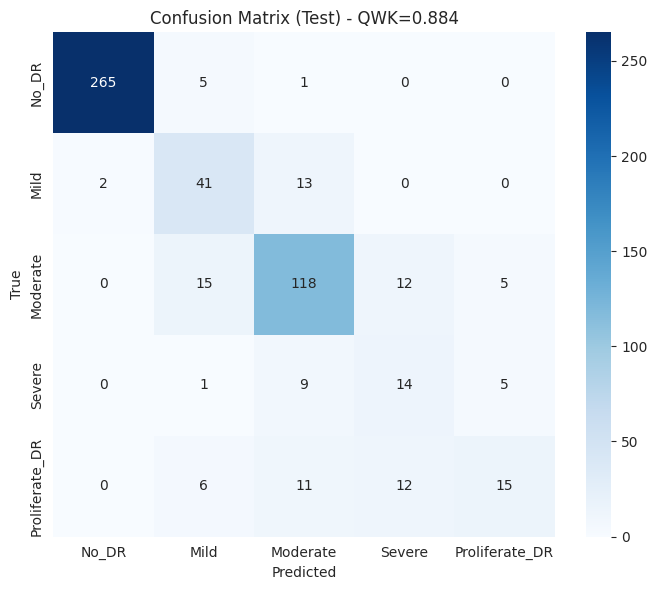

In [21]:
# @title 9b. Classification report, confusion matrix, QWK (test set)
IDX_TO_LABEL = {v: k for k, v in DRDataset.LABEL_TO_IDX.items()}
class_names = [IDX_TO_LABEL[i] for i in range(NUM_CLASSES)]

test_acc = accuracy_score(all_labels, all_preds)
test_qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test QWK      : {test_qwk:.4f}\n")

print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix (Test) - QWK={test_qwk:.3f}")
plt.tight_layout()
plt.show()

Rata-rata predictive entropy:
  Prediksi BENAR : 0.3580 (n=453)
  Prediksi SALAH : 0.7327 (n=97)


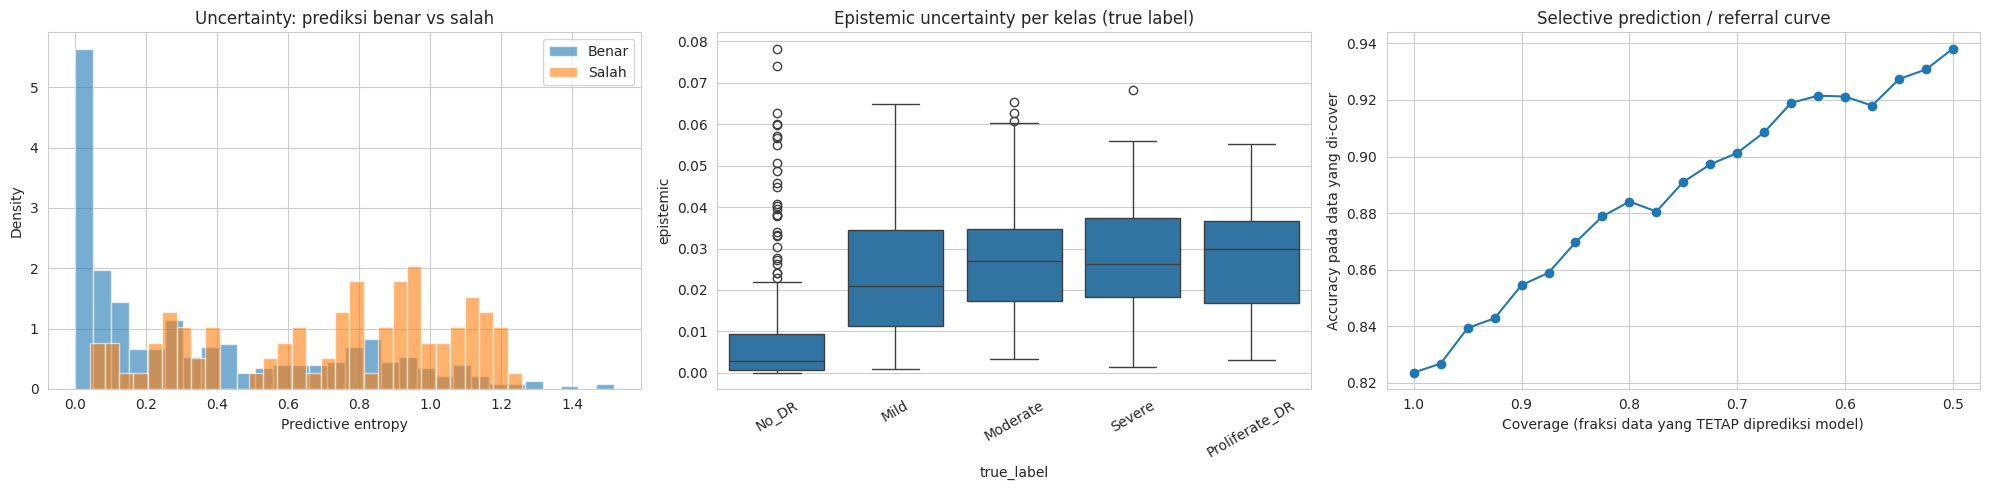

In [22]:
# @title 9c. Analisis uncertainty: benar vs salah, per kelas, & referral curve
is_correct = all_preds == all_labels

print("Rata-rata predictive entropy:")
print(
    f"  Prediksi BENAR : {all_predictive_entropy[is_correct].mean():.4f} (n={is_correct.sum()})"
)
print(
    f"  Prediksi SALAH : {all_predictive_entropy[~is_correct].mean():.4f} (n={(~is_correct).sum()})"
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# (1) distribusi predictive entropy: benar vs salah
axes[0].hist(
    all_predictive_entropy[is_correct], bins=30, alpha=0.6, label="Benar", density=True
)
axes[0].hist(
    all_predictive_entropy[~is_correct], bins=30, alpha=0.6, label="Salah", density=True
)
axes[0].set_xlabel("Predictive entropy")
axes[0].set_ylabel("Density")
axes[0].set_title("Uncertainty: prediksi benar vs salah")
axes[0].legend()

# (2) epistemic uncertainty per kelas asli
df_unc = pd.DataFrame(
    {
        "true_label": [class_names[i] for i in all_labels],
        "epistemic": all_epistemic_uncertainty,
        "aleatoric": all_aleatoric_entropy,
        "correct": is_correct,
    }
)
sns.boxplot(data=df_unc, x="true_label", y="epistemic", order=class_names, ax=axes[1])
axes[1].set_title("Epistemic uncertainty per kelas (true label)")
axes[1].tick_params(axis="x", rotation=30)

# (3) referral / selective-prediction curve: kalau kita "tolak" (refer ke dokter)
# sekian persen sample paling tidak-yakin, seberapa naik akurasi pada sisanya?
order_idx = np.argsort(-all_predictive_entropy)  # paling tidak yakin duluan
sorted_correct = is_correct[order_idx]
n = len(sorted_correct)
coverage, sel_acc = [], []
for reject_frac in np.linspace(0, 0.5, 21):
    n_reject = int(reject_frac * n)
    kept = sorted_correct[n_reject:]
    coverage.append(1 - reject_frac)
    sel_acc.append(kept.mean() if len(kept) > 0 else np.nan)

axes[2].plot(coverage, sel_acc, marker="o")
axes[2].set_xlabel("Coverage (fraksi data yang TETAP diprediksi model)")
axes[2].set_ylabel("Accuracy pada data yang di-cover")
axes[2].set_title("Selective prediction / referral curve")
axes[2].invert_xaxis()

plt.tight_layout()
plt.show()